# 038 容量过参数化与理论边界
先读lecture.pdf和lab.pdf。重启内核，按顺序运行。所有数值重新计算；3张展示图来自独立重建核验的冻结PNG。没有Jupyter UI或跨平台安装保证。

In [1]:
from pathlib import Path
import hashlib, json, csv, io, os, sys, tempfile, importlib.util
ROOT = Path.cwd()
if not (ROOT / "experiment.py").is_file():
    candidate = ROOT / "units" / "038"
    if candidate.is_dir(): ROOT = candidate
EXPECTED = {'experiment.py': 'fa34627aed0d37ac59fdf016508c3b2c560f6e79ca8d6d33454f135910f9c48e', 'test_experiment.py': '289aa2990cb5567c8177b917aab52bc41e817b54dbede8e4d136f6605b0fac28', 'make_figures.py': 'cfe7d8a8f0dd6252f5adbd246d46a7a21481f7df44783c1d4a53b66d8f9c6883', 'environment.yml': '1e3bbd249fff1df44aef49f4ccc073b24c6f8b27f3d8b4c8afd434b60cfc8f60', 'data/gaussian-fixture.json': '5918bdbd00997445ba621d8c0b95e989042535bb6bb5e6c93ed3eb89ddb8a90e', 'outputs/capacity-detail.json': 'bc641daa28438ea552cea2d103e8fc322fc1c6b60e9557c4b22e8dcd1e445b1e', 'outputs/capacity.csv': 'c701a6318227f9cc6352f06074475deee6c0d0735427e94a9b379ea426c89ff8', 'outputs/conditional-risk.json': '1ad15ff09fc4e15a380298a4d45a12594d6cada0296b6f42c8351fe3691dc757', 'outputs/duplication.json': 'b28a023672dd983287e04ef271d6eefeb164f3b348a84212f6e9ec04ef33a1e5', 'outputs/finite-class-bound.json': '6b17be79d708d83462049bba64f017f488d006d59f72e7440edb9139ef920221', 'outputs/hand-trace.json': 'f5d65226cc0d8caa795b2c5005cdeb58fc7df393516fe62d4ebea4bd36752637', 'outputs/implicit-bias.json': '8c243fe95f65c35895fd1f69b1f8c9a1da36a8c79ce70fe46f227abe66f60895', 'outputs/spectral-filters.json': 'ac1d2d30f75d43c3893aae376da487a41e7307ba5474c3945e80a16a5cc3acbb', 'outputs/summary.json': '6e18ec0e444a6983e7d784695911302b54f1e0f8e0b9b58947e3f186466b26ba', 'figures/01-capacity-levels.png': '2684aa1b157cfea24a90a7ff6eb5877a495fab5be3af1f79da90c84826d80fbb', 'figures/02-gradient-contributions.png': '51d4ac020ed5d1f12d830f02222a9bd53e64221a50f139434435eaccf7b8275d', 'figures/03-null-space.png': 'f9d5767e72a1a1c2439906dbc42f8769b9d3c06baad5ed5e3c06ae5dfe5e48ff', 'figures/04-spectral-filter.png': 'dbb24338d37e3c5340ed4154bffa1ac05432e5e15ae0496d7fe690b8a7ddec6f', 'figures/05-neuron-duplication.png': 'ae4ea2d1bd5e5a3cebab86e7e629126ef8044fd7a017d0072ead7bebabd27b4f', 'figures/06-experiment-design.png': '9a0b8635c57fbeec255551748b1cadfbf8dfa2b17d122f347f9856938a0a5361', 'figures/07-capacity-noise.png': '1184fc81f91fcf1cd3b7c6101cbd95b01994d1ecc973c8ea7aad0babda249e45', 'figures/08-ridge-control.png': 'c620f034bf3343561d88e781bc601a9f64aeb6553acd75d2f406c0bd173fedb9', 'figures/09-spectrum-risk.png': 'b910992cac8fdc5969db80929a307c2dc772a6bdc33aed170e33b70f78414f5d', 'figures/10-risk-expectations.png': 'ab72989b146f7e247f0c642f2c9bdbb650913af7e4333aa209f8f18cb747c989', 'figures/11-theory-boundaries.png': 'efc2f7b0cb66f2f843b708748ccc55db66d1e3530d1dc7afa8fef4d79362a6eb', 'figures/12-finite-bound.png': '8491b0b46b1a3b813e9c848cd62eb867494e06330c2644cee4d8a6ef9d84756b'}
for relative, digest in EXPECTED.items():
    path = ROOT / relative
    if not path.is_file() or hashlib.sha256(path.read_bytes()).hexdigest() != digest:
        raise ValueError("基准文件缺失或改动：" + relative)
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
sys.path.insert(0, str(ROOT))
spec = importlib.util.spec_from_file_location("experiment", ROOT / "experiment.py")
e = importlib.util.module_from_spec(spec)
sys.modules["experiment"] = e
spec.loader.exec_module(e)
import numpy as np
import torch
torch.set_num_threads(1)
print("全部26个基准文件守卫通过；开始重新计算。")

全部26个基准文件守卫通过；开始重新计算。


## 1 环境与同一两样本
半平方损失平均到两个样本。请先在纸上计算，再展开数值。

In [2]:
print({"numpy": np.__version__, "torch": torch.__version__, "dtype": "float64", "device": "CPU"})
print("X", e.X_HAND.tolist(), "y", e.Y_HAND.tolist())

{'numpy': '2.3.5', 'torch': '2.7.1+cpu', 'dtype': 'float64', 'device': 'CPU'}
X [[1.0, 0.0, 1.0], [0.0, 1.0, 1.0]] y [1.0, 2.0]


In [3]:
hand = e.hand_trace()
for index, step in enumerate(hand["steps"]):
    print("step", index, "prediction", step["prediction"].tolist(), "loss", step["loss"])
    print("local dL/dprediction", step["dloss_dpred"].tolist())
    print("sample contributions", step["contributions"].tolist())
    print("gradient", step["gradient"].tolist(), "after", step["after"].tolist())
    print("next forward", step["next_prediction"].tolist(), step["next_loss"])

step 0 prediction [0.0, 0.0] loss 1.25
local dL/dprediction [-0.5, -1.0]
sample contributions [[-0.5, -0.0, -0.5], [-0.0, -1.0, -1.0]]
gradient [-0.5, -1.0, -1.5] after [0.25, 0.5, 0.75]
next forward [1.0, 1.25] 0.140625
step 1 prediction [1.0, 1.25] loss 0.140625
local dL/dprediction [0.0, -0.375]
sample contributions [[0.0, 0.0, 0.0], [-0.0, -0.375, -0.375]]
gradient [0.0, -0.375, -0.375] after [0.25, 0.6875, 0.9375]
next forward [1.1875, 1.625] 0.0439453125


## 2 插值解与算法选择
训练预测相同并不限制新点预测。零空间分量在本例普通GD中保持。

In [4]:
bias = e.implicit_bias()
for path in bias["paths"]:
    last = path["rows"][-1]
    print("initial null coefficient", path["null_coefficient"], "last w", last["w"].tolist(), "new point", float(last["w"] @ bias["query"]))
print("rescaled coefficients", bias["rescaled_function_coefficients"].tolist())

initial null coefficient 0.0 last w [5.056743912490447e-11, 0.9999999999494327, 1.0] new point 1.0
initial null coefficient 1.0 last w [-0.9999999999494327, -5.056743912490447e-11, 2.0] new point -1.0
initial null coefficient -1.0 last w [1.0000000000505676, 1.9999999999494324, 0.0] new point 3.0
rescaled coefficients [-0.33333333333333337, 0.6666666666666664, 1.3333333333333335]


## 3 复制节点的完整网络链
两种网络使用同一个X、y。样本1贡献为零也保留，输出偏置只算一次。

In [5]:
for width in [1, 2]:
    d = e.neural_step(width)
    print("width", width, "order", d["parameter_order"])
    for key in ["z", "h", "prediction", "residual", "loss", "dloss_dprediction", "dpred_dh", "dh_dz", "dloss_dz", "sample_contributions", "gradient", "after", "next_z", "next_prediction", "next_loss"]:
        print(key, e.serializable(d[key]))

width 1 order ['W11', 'W12', 'W13', 'b1', 'a1', 'c']
z [[1.0], [1.5]]
h [[1.0], [1.5]]
prediction [1.0, 1.5]
residual [0.0, -0.5]
loss 0.0625
dloss_dprediction [0.0, -0.25]
dpred_dh [1.0]
dh_dz [[1.0], [1.0]]
dloss_dz [[0.0], [-0.25]]
sample_contributions [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [-0.0, -0.25, -0.25, -0.25, -0.375, -0.25]]
gradient [0.0, -0.25, -0.25, -0.25, -0.375, -0.25]
after [0.5, 1.05, 0.05, 0.55, 1.075, 0.05]
next_z [[1.1], [1.6500000000000001]]
next_prediction [1.2325000000000002, 1.8237500000000002]
next_loss 0.021280078124999997
width 2 order ['W11', 'W12', 'W13', 'W21', 'W22', 'W23', 'b1', 'b2', 'a1', 'a2', 'c']
z [[1.0, 1.0], [1.5, 1.5]]
h [[1.0, 1.0], [1.5, 1.5]]
prediction [1.0, 1.5]
residual [0.0, -0.5]
loss 0.0625
dloss_dprediction [0.0, -0.25]
dpred_dh [0.5, 0.5]
dh_dz [[1.0, 1.0], [1.0, 1.0]]
dloss_dz [[0.0, 0.0], [-0.125, -0.125]]
sample_contributions [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [-0.0, -0.125, -0.125, -0.0, -0.125, -0.125, -0.125,

## 4 重算全部实验
1944个直接拟合，不是神经网络的1944次epoch。计算完成并序列化后才写临时目录；与9份基准数值文件逐字节比较。

In [6]:
with tempfile.TemporaryDirectory(prefix="dl038-notebook-") as temporary:
    summary = e.run(Path(temporary))
    for source in sorted((ROOT / "outputs").glob("*")):
        actual = Path(temporary) / source.name
        if source.read_bytes() != actual.read_bytes():
            raise ValueError("重算结果不一致：" + source.name)
print("9份数值产物重新计算且字节一致；fits", summary["fit_count"])
rows = list(csv.DictReader((ROOT / "outputs/capacity.csv").open()))

9份数值产物重新计算且字节一致；fits 1944


In [7]:
for sigma in [0., .2, .8]:
    print("sigma", sigma)
    for p in [3, 24, 32, 48, 96]:
        r = [float(z["clean_risk"]) for z in rows if int(z["p"]) == p and float(z["sigma"]) == sigma and float(z["ridge"]) == 0]
        print(p, {"median": float(np.median(r)), "mean": float(np.mean(r)), "min": min(r), "max": max(r)})

sigma 0.0
3 {'median': 5.192307130067988e-31, 'mean': 7.041199876679734e-31, 'min': 9.860761315262648e-32, 'max': 2.0214560696288428e-30}
24 {'median': 3.240905868790524e-29, 'mean': 2.182450223039567e-28, 'min': 3.3809350464148556e-30, 'max': 2.0899735198246006e-27}
32 {'median': 0.459400554398947, 'mean': 0.5499592309832341, 'min': 0.26506766740229165, 'max': 1.1119514102932924}
48 {'median': 1.0268884871622088, 'mean': 1.1114220325376882, 'min': 0.7072045474937608, 'max': 1.6120550111573055}
96 {'median': 1.6751113019126809, 'mean': 1.6736189171184976, 'min': 1.392067908892914, 'max': 1.9353667995197217}
sigma 0.2
3 {'median': 0.006889824958010991, 'mean': 0.007448399579822881, 'min': 0.0014283515518466747, 'max': 0.017344369621478253}
24 {'median': 3.028670400917378, 'mean': 6.700473460902021, 'min': 0.49590212107372217, 'max': 29.034900427917034}
32 {'median': 0.5866130945827029, 'mean': 0.7203713065905256, 'min': 0.4445730050664959, 'max': 1.398164322867014}
48 {'median': 1.07297

## 5 风险拆分
显式保留遗漏信号、实际噪声响应及交叉项。仅在对训练噪声取期望后，交叉项的期望才必为零。

In [8]:
for row in rows:
    total = float(row["signal_error"]) + float(row["realized_noise_norm2"]) + float(row["cross_term"])
    if not np.isclose(total, float(row["clean_risk"]), rtol=1e-11, atol=1e-10):
        raise ValueError("risk decomposition mismatch")
example = next(z for z in rows if int(z["p"]) == 2 and float(z["sigma"]) == .8 and float(z["ridge"]) == .1)
print({k: example[k] for k in ["seed", "p", "signal_error", "realized_noise_norm2", "cross_term", "clean_risk", "conditional_noise_mean_risk"]})

{'seed': '3800', 'p': '2', 'signal_error': '0.2565170159815989', 'realized_noise_norm2': '0.04367436890640299', 'cross_term': '-0.033687639190477035', 'clean_risk': '0.2665037456975249', 'conditional_noise_mean_risk': '0.29768384990055446'}


In [9]:
mc = e.conditional_demo()
for key in ["noise_expected_risk", "noise_mean", "noise_mcse", "exact_fixed_fit_risk", "test_clean_mse", "test_mcse"]:
    print(key, mc[key])
print("400次训练噪声重抽只固定一个设计；4096个新输入只检查一个固定拟合。")

noise_expected_risk 2.6353784575047277
noise_mean 2.576102978702686
noise_mcse 0.06737108653816833
exact_fixed_fit_risk 2.4533599118620844
test_clean_mse 2.456786668011624
test_mcse 0.05463093103966622
400次训练噪声重抽只固定一个设计；4096个新输入只检查一个固定拟合。


## 6 谱滤波和有限候选上界
两组工具都带前提，不能把有界有限函数类界直接套到这里的Gaussian平方损失。

In [10]:
spectral = e.spectral_demo()
for state in spectral["gd"]:
    print("steps", state["steps"], "w", state["w"].tolist(), "prediction", state["prediction"].tolist(), "loss", state["loss"])

steps 0 w [0.0, 0.0] prediction [0.0, 0.0] loss 0.5
steps 1 w [0.4, 0.040000000000000036] prediction [0.8, 0.008000000000000007] loss 0.25601599999999997
steps 2 w [0.48, 0.0796800000000003] prediction [0.96, 0.01593600000000006] loss 0.24249548902399998
steps 10 w [0.4999999488, 0.38590294021368376] prediction [0.9999998976, 0.07718058804273675] loss 0.2128989167712899
steps 100 w [0.5, 2.7605714029846085] prediction [1.0, 0.5521142805969217] loss 0.05015040441130325
steps 1000 w [0.5, 4.998375790080516] prediction [1.0, 0.9996751580161032] loss 2.6380578625505063e-08


In [11]:
for row in e.bound_demo():
    if row["M"] == 1000000: print(row)
print("epsilon大于1只表示这个界没有优于有界损失的平凡限制，不能据此说模型差。")

{'n': 5, 'M': 1000000, 'delta': 0.05, 'epsilon': 1.3230415719877517}
{'n': 24, 'M': 1000000, 'delta': 0.05, 'epsilon': 0.6038830945789889}
{'n': 100, 'M': 1000000, 'delta': 0.05, 'epsilon': 0.2958410892022794}
{'n': 1000, 'M': 1000000, 'delta': 0.05, 'epsilon': 0.0935531667344249}
epsilon大于1只表示这个界没有优于有界损失的平凡限制，不能据此说模型差。


## 7 独立参考测试
Fraction两轮、全部1944个lstsq/增广Ridge参考、34个逐样本神经网络参数导数、160个随机线性复步坐标，以及边界/坏输入守卫。

In [12]:
import unittest, test_experiment
suite = unittest.defaultTestLoader.loadTestsFromModule(test_experiment)
result = unittest.TextTestRunner(stream=sys.stdout, verbosity=1).run(suite)
if not result.wasSuccessful(): raise RuntimeError("independent reference tests failed")

.

.

.

.

.

...

.

.

.

.

----------------------------------------------------------------------
Ran 18 tests in 1.501s

OK


## 8 原创图与证据范围
静态PNG展示，不假装Notebook重新绘图；make_figures.py另可重建全部12张并核验输入。容量图给全部seed与中位数，理论图提示不可越界的条件。

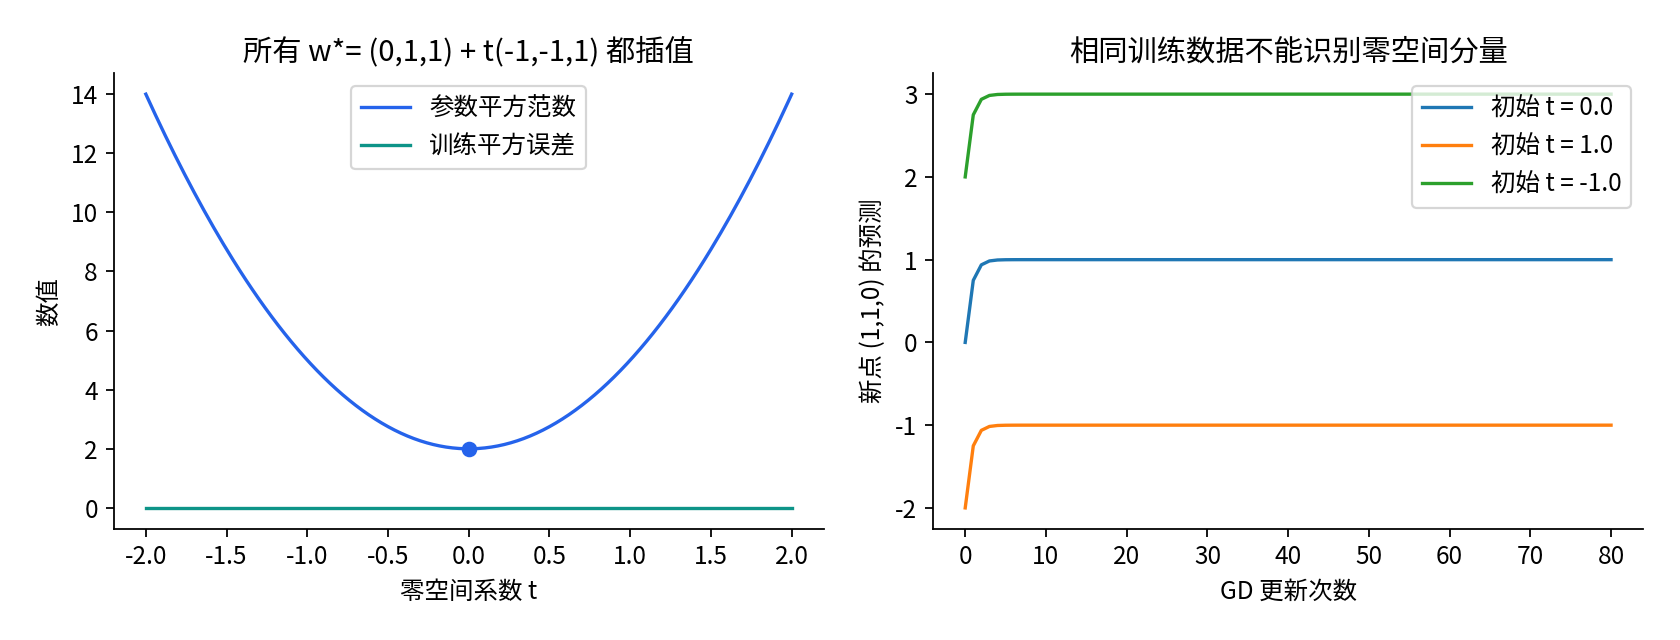

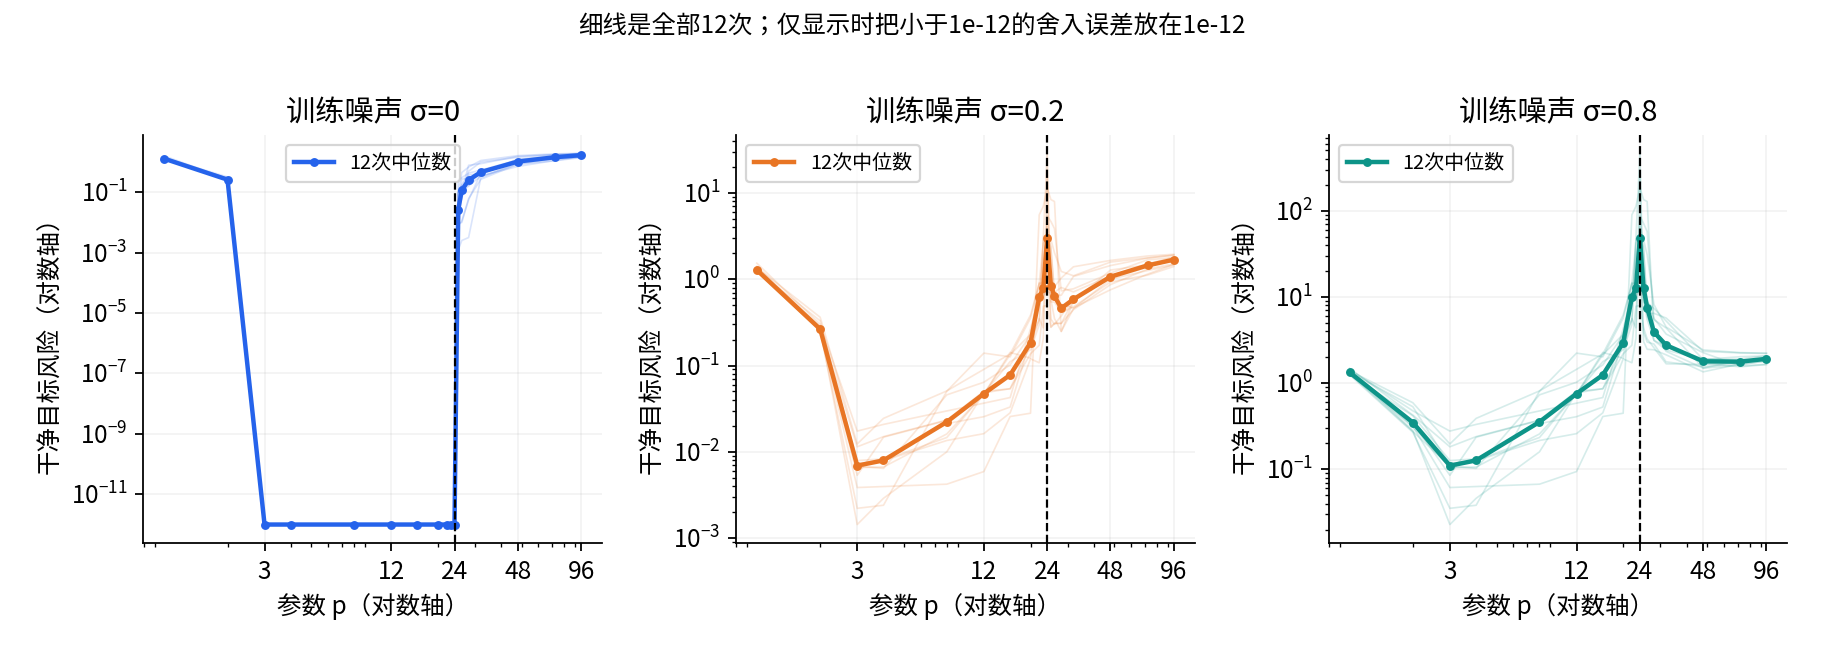

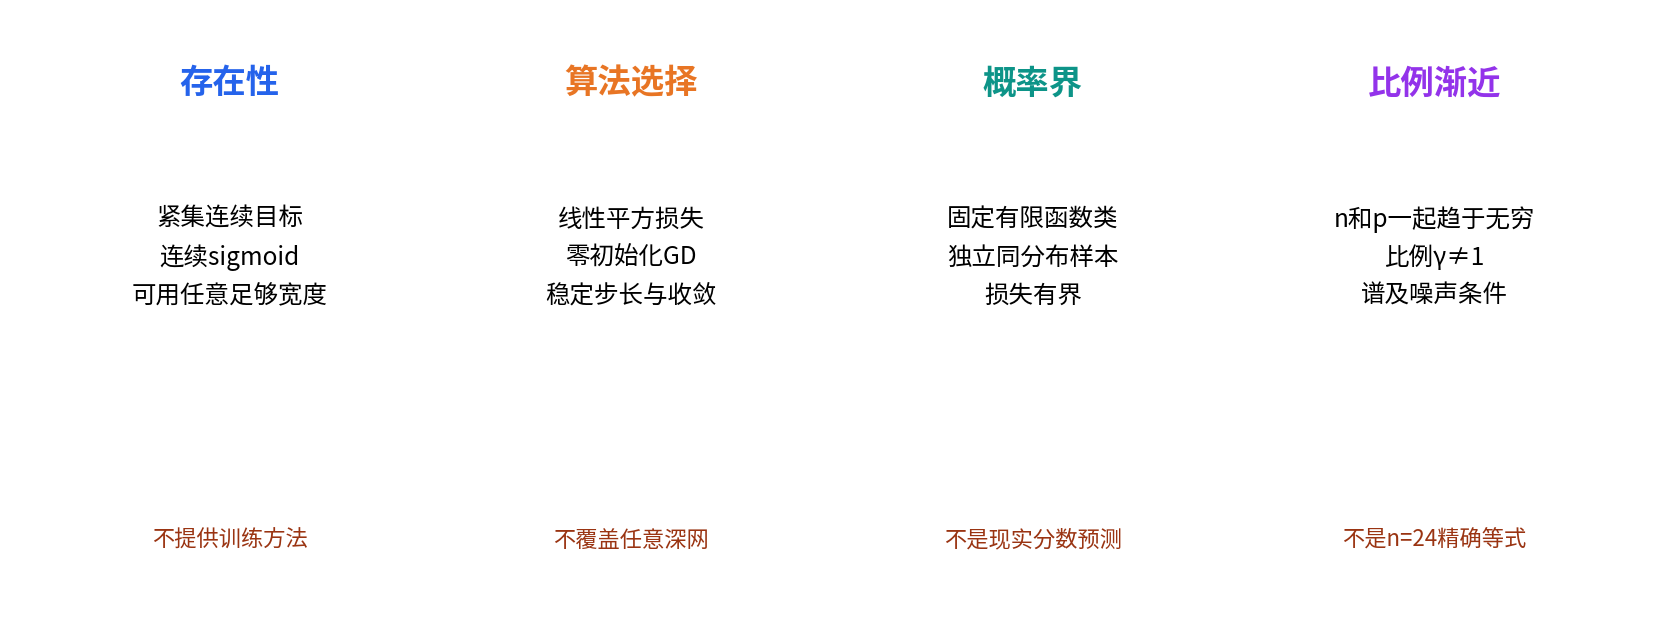

In [13]:
from IPython.display import Image, display
for name in ["03-null-space.png", "07-capacity-noise.png", "11-theory-boundaries.png"]:
    display(Image(filename=str(ROOT / "figures" / name)))

## 9 研究记录
写下两条支持、两条不支持的结论。特别说明无噪声对照和p=48到96再变差。保留所有失败结果，按lab.pdf设计一次单因素扩展。

In [14]:
print("完成：12个seed全部保留；没有真实任务、GPU、普遍双下降或最优λ结论。")

完成：12个seed全部保留；没有真实任务、GPU、普遍双下降或最优λ结论。
